# 03 Uncertainty and Error Maps (Summary-Level)

This notebook links uncertainty-style signals to the failure taxonomy output from `01_failure_case_taxonomy.ipynb`.

Main goals:
- quantify uncertainty by failure type
- check how uncertainty relates to IoU / FP / FN
- export report-ready CSV tables and figures


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

ROOT = Path('/users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite')
OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('OUT_DIR =', OUT_DIR)


ROOT = /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite
OUT_DIR = /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs


In [2]:
files = sorted(OUT_DIR.glob('failure_taxonomy_*.csv'))
if not files:
    raise FileNotFoundError('No failure_taxonomy_*.csv found in outputs/.')

frames = []
for f in files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    if 'model_name' not in df.columns:
        model_guess = f.stem.replace('failure_taxonomy_', '')
        df['model_name'] = model_guess
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
print('Loaded rows:', len(all_df))
print('Columns:', list(all_df.columns))
all_df.head(2)


Loaded rows: 145
Columns: ['sample_id', 'gt_pixels', 'pred_pixels', 'tp_pixels', 'fp_pixels', 'fn_pixels', 'iou', 'f1', 'precision', 'recall', 'mean_prob_on_gt', 'mean_prob_on_fp', 'mean_uncertainty', 'image_brightness', 'fp_brightness', 'fn_brightness', 'image_edge_strength', 'fp_edge_strength', 'fn_edge_strength', 'fp_overlap_water_pixels', 'fp_overlap_leaching_pixels', 'fp_overlap_noncrack_ratio', 'pred_components', 'pred_largest_area', 'pred_max_elongation', 'gt_components', 'gt_largest_area', 'gt_max_elongation', 'candidate_failure_type', 'image_name', 'image_abs_path', 'raw_mask_path', 'decision_threshold', 'setting', 'model_name', 'source_file', 'review_target_type', 'human_failure_type', 'notes']


,sample_id,gt_pixels,pred_pixels,tp_pixels,fp_pixels,fn_pixels,iou,f1,precision,recall,...,image_name,image_abs_path,raw_mask_path,decision_threshold,setting,model_name,source_file,review_target_type,human_failure_type,notes
0,0,0,1002,0,1002,0,0.0,0.0,0.0,0.0,...,TB_Camera7_000012_E.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-efficientnet-b0-imagenet_Single-TB,failure_taxonomy_Unet-efficientnet-b0-imagenet...,NaN,NaN,NaN
1,1,0,46,0,46,0,0.0,0.0,0.0,0.0,...,TB_Camera3_001107_H.png,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,/users/7/yu001011/csci5527/CSCI5527-final/TACK...,0.5,Single-TB,Unet-efficientnet-b0-imagenet_Single-TB,failure_taxonomy_Unet-efficientnet-b0-imagenet...,NaN,NaN,NaN


In [3]:
# Normalize failure label column
label_col = 'candidate_failure_type' if 'candidate_failure_type' in all_df.columns else None
if label_col is None:
    all_df['failure_type'] = 'unknown'
else:
    all_df['failure_type'] = all_df[label_col].fillna('unknown').astype(str)

# Keep metrics we need
needed = [
    'model_name', 'setting', 'sample_id', 'image_name', 'failure_type',
    'iou', 'f1', 'precision', 'recall',
    'tp_pixels', 'fp_pixels', 'fn_pixels', 'pred_pixels', 'gt_pixels',
    'mean_prob_on_gt', 'mean_prob_on_fp', 'mean_uncertainty'
]
keep_cols = [c for c in needed if c in all_df.columns]
df = all_df[keep_cols].copy()

for c in ['iou','f1','precision','recall','mean_prob_on_gt','mean_prob_on_fp','mean_uncertainty','tp_pixels','fp_pixels','fn_pixels','pred_pixels','gt_pixels']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df['failure_type'] = df['failure_type'].fillna('unknown')
df.head(3)


,model_name,setting,sample_id,image_name,failure_type,iou,f1,precision,recall,tp_pixels,fp_pixels,fn_pixels,pred_pixels,gt_pixels,mean_prob_on_gt,mean_prob_on_fp,mean_uncertainty
0,Unet-efficientnet-b0-imagenet_Single-TB,Single-TB,0,TB_Camera7_000012_E.png,fp_dark_shadow_candidate,0.0,0.0,0.0,0.0,0,1002,0,1002,0,NaN,0.899571,0.004757
1,Unet-efficientnet-b0-imagenet_Single-TB,Single-TB,1,TB_Camera3_001107_H.png,mixed_or_unclear_failure,0.0,0.0,0.0,0.0,0,46,0,46,0,NaN,0.817907,0.002197
2,Unet-efficientnet-b0-imagenet_Single-TB,Single-TB,2,TB_Camera4_000334_N.png,mixed_or_unclear_failure,0.0,0.0,0.0,0.0,0,76,0,76,0,NaN,0.789885,0.002681


In [4]:
summary = (
    df.groupby(['model_name', 'failure_type'], dropna=False)
      .agg(
          n_samples=('sample_id', 'count'),
          mean_iou=('iou', 'mean'),
          mean_f1=('f1', 'mean'),
          mean_precision=('precision', 'mean'),
          mean_recall=('recall', 'mean'),
          mean_uncertainty=('mean_uncertainty', 'mean'),
          mean_prob_on_gt=('mean_prob_on_gt', 'mean'),
          mean_prob_on_fp=('mean_prob_on_fp', 'mean'),
          fp_pixels=('fp_pixels', 'sum'),
          fn_pixels=('fn_pixels', 'sum'),
      )
      .reset_index()
      .sort_values(['model_name', 'mean_uncertainty'], ascending=[True, False])
)

out_csv = OUT_DIR / 'uncertainty_by_failure_type.csv'
summary.to_csv(out_csv, index=False)
print('Saved:', out_csv)
summary.head(20)


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/uncertainty_by_failure_type.csv


,model_name,failure_type,n_samples,mean_iou,mean_f1,mean_precision,mean_recall,mean_uncertainty,mean_prob_on_gt,mean_prob_on_fp,fp_pixels,fn_pixels
16,Unet-efficientnet-b0-imagenet_Single-TB,"missed_low_confidence_crack, fragmented_or_thi...",2,0.268853,0.423773,0.747688,0.295679,0.010512,0.297724,0.921619,2346,16560
13,Unet-efficientnet-b0-imagenet_Single-TB,missed_low_confidence_crack,3,0.119354,0.202461,0.664928,0.119410,0.005332,0.126129,0.682018,4,7580
9,Unet-efficientnet-b0-imagenet_Single-TB,"fragmented_or_thin_crack, fp_dark_shadow_candi...",2,0.137275,0.241410,0.166563,0.438424,0.005269,0.433154,0.919485,2672,684
5,Unet-efficientnet-b0-imagenet_Single-TB,"fp_edge_or_seam_candidate, fp_long_linear_stru...",4,0.066445,0.104987,0.082988,0.142857,0.004946,0.183665,0.848490,808,175
14,Unet-efficientnet-b0-imagenet_Single-TB,"missed_low_confidence_crack, fp_long_linear_st...",2,0.000000,0.000000,0.000000,0.000000,0.004785,0.010072,0.852808,454,466
0,Unet-efficientnet-b0-imagenet_Single-TB,fp_dark_shadow_candidate,2,0.000000,0.000000,0.000000,0.000000,0.004757,NaN,0.899571,2004,0
8,Unet-efficientnet-b0-imagenet_Single-TB,"fragmented_or_thin_crack, fp_dark_shadow_candi...",4,0.511524,0.672528,0.762495,0.618354,0.004273,0.613803,0.885470,1799,2704
3,Unet-efficientnet-b0-imagenet_Single-TB,"fp_dark_shadow_candidate, fp_long_linear_struc...",5,0.000000,0.000000,0.000000,0.000000,0.004013,NaN,0.900558,2588,0
11,Unet-efficientnet-b0-imagenet_Single-TB,"fragmented_or_thin_crack, fp_long_linear_struc...",1,0.375813,0.546314,0.734746,0.434804,0.003996,0.429629,0.866255,313,1127
2,Unet-efficientnet-b0-imagenet_Single-TB,"fp_dark_shadow_candidate, fp_edge_or_seam_cand...",4,0.461892,0.614962,0.506045,0.788493,0.003805,0.780840,0.910133,2516,546


In [5]:
# Global uncertainty quantile analysis
q = df['mean_uncertainty'].quantile([0.2, 0.4, 0.6, 0.8]).values
bins = [-np.inf, *q, np.inf]
labels = ['Q1(low)', 'Q2', 'Q3', 'Q4', 'Q5(high)']
df['uncertainty_bin'] = pd.cut(df['mean_uncertainty'], bins=bins, labels=labels)

quant_summary = (
    df.groupby(['model_name', 'uncertainty_bin'], dropna=False)
      .agg(
          n_samples=('sample_id', 'count'),
          mean_iou=('iou', 'mean'),
          mean_f1=('f1', 'mean'),
          mean_precision=('precision', 'mean'),
          mean_recall=('recall', 'mean'),
          fp_pixels=('fp_pixels', 'sum'),
          fn_pixels=('fn_pixels', 'sum'),
      )
      .reset_index()
)

out_csv2 = OUT_DIR / 'uncertainty_quantile_performance.csv'
quant_summary.to_csv(out_csv2, index=False)
print('Saved:', out_csv2)
quant_summary


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/uncertainty_quantile_performance.csv


,model_name,uncertainty_bin,n_samples,mean_iou,mean_f1,mean_precision,mean_recall,fp_pixels,fn_pixels
0,Unet-efficientnet-b0-imagenet_Single-TB,Q1(low),29,0.078094,0.120833,0.134533,0.130683,4646,2476
1,Unet-efficientnet-b0-imagenet_Single-TB,Q2,29,0.190156,0.275603,0.342999,0.275420,12119,17421
2,Unet-efficientnet-b0-imagenet_Single-TB,Q3,14,0.141891,0.200719,0.235456,0.211422,6792,19278
3,Unet-resnet34-imagenet_Single-TB,Q3,15,0.273386,0.404274,0.363100,0.544616,10987,8077
4,Unet-resnet34-imagenet_Single-TB,Q4,29,0.176184,0.253008,0.291330,0.279224,8586,12779
5,Unet-resnet34-imagenet_Single-TB,Q5(high),29,0.071463,0.091639,0.082592,0.114883,6486,6127


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/fig_uncertainty_vs_iou.png


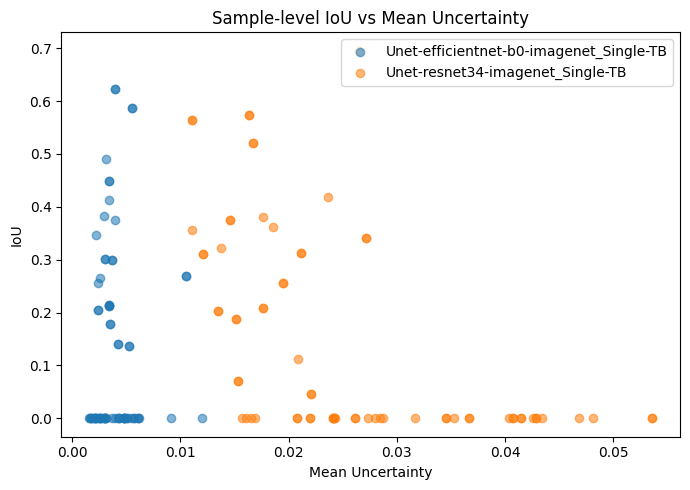

In [6]:
# Figure 1: uncertainty vs IoU
fig, ax = plt.subplots(figsize=(7, 5))
if sns is not None:
    sns.scatterplot(data=df, x='mean_uncertainty', y='iou', hue='model_name', alpha=0.55, ax=ax)
else:
    for m, g in df.groupby('model_name'):
        ax.scatter(g['mean_uncertainty'], g['iou'], alpha=0.55, label=m)
    ax.legend()

ax.set_title('Sample-level IoU vs Mean Uncertainty')
ax.set_xlabel('Mean Uncertainty')
ax.set_ylabel('IoU')
fig.tight_layout()
fig_path = OUT_DIR / 'fig_uncertainty_vs_iou.png'
fig.savefig(fig_path, dpi=180)
print('Saved:', fig_path)
plt.show()


/tmp/ipykernel_4145314/2289724158.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/fig_uncertainty_by_failure_type.png


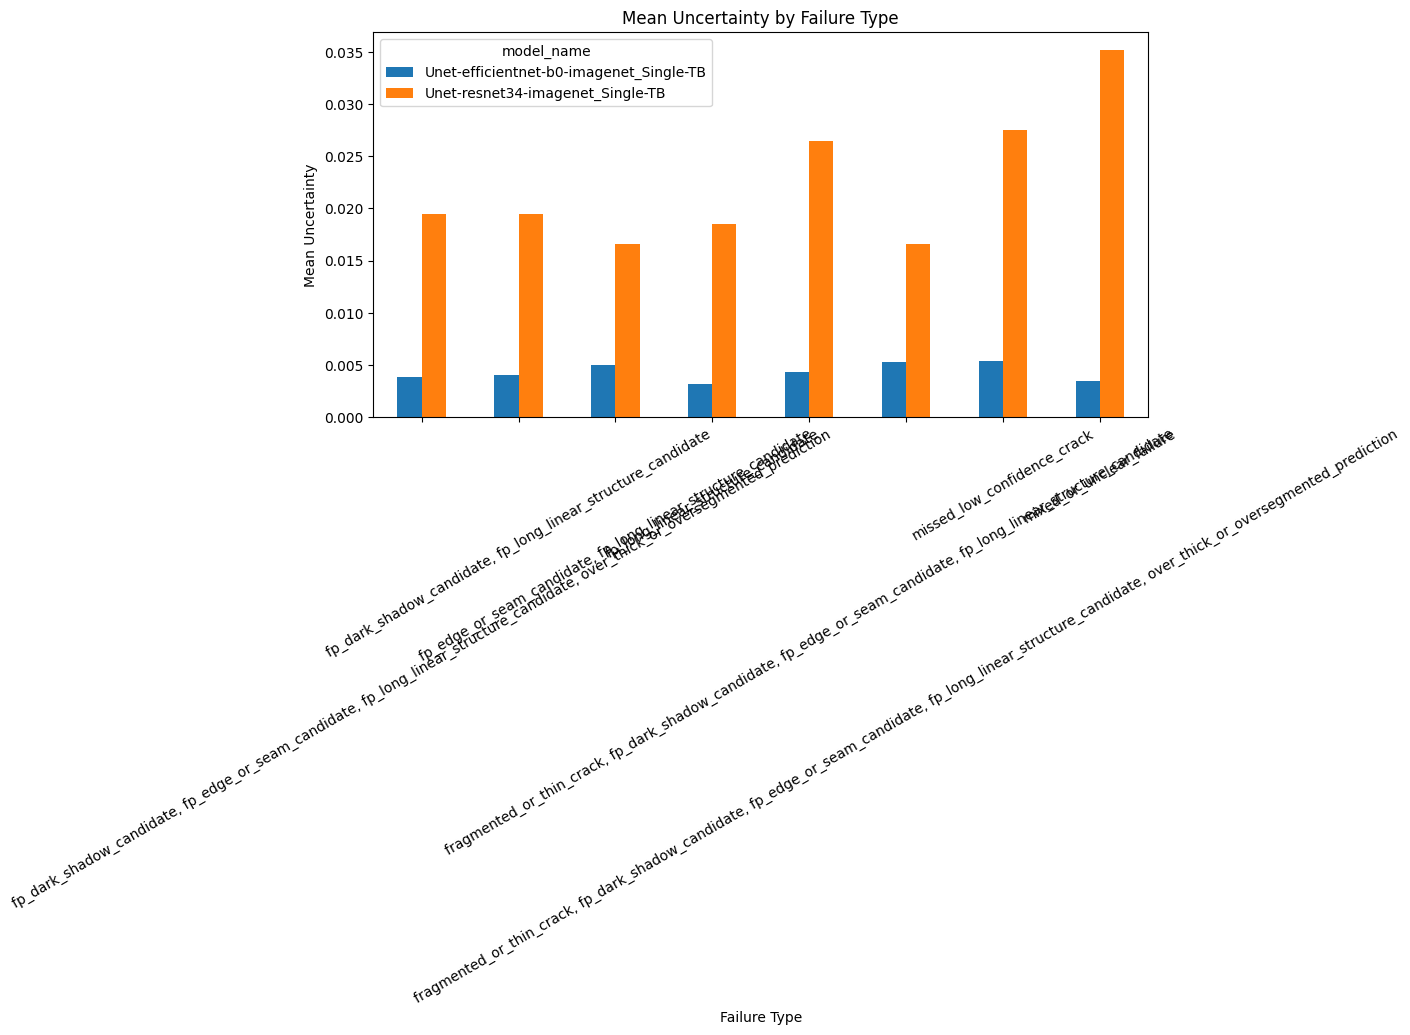

In [7]:
# Figure 2: failure-type uncertainty (top types by frequency)
top_types = df['failure_type'].value_counts().head(8).index
dfp = df[df['failure_type'].isin(top_types)].copy()

fig, ax = plt.subplots(figsize=(10, 5))
if sns is not None:
    sns.boxplot(data=dfp, x='failure_type', y='mean_uncertainty', hue='model_name', ax=ax)
else:
    # fallback: grouped means only
    grp = dfp.groupby(['failure_type','model_name'])['mean_uncertainty'].mean().unstack(fill_value=np.nan)
    grp.plot(kind='bar', ax=ax)

ax.set_title('Mean Uncertainty by Failure Type')
ax.set_xlabel('Failure Type')
ax.set_ylabel('Mean Uncertainty')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig_path = OUT_DIR / 'fig_uncertainty_by_failure_type.png'
fig.savefig(fig_path, dpi=180)
print('Saved:', fig_path)
plt.show()


## Notes

- This notebook is summary-level explainability on top of existing taxonomy CSVs.
- If you later save per-pixel probability maps, you can extend this to true pixel-wise entropy maps and TP/FP/FN overlays.
